# Análisis Exploratorio de Redes Sociales y Resultados Electorales

Este notebook realiza un análisis integrando los datos unificados de Facebook, TikTok y Twitter con los resultados electorales oficiales.

## **1. Análisis por interacciones totales**

In [39]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

# Definición de rutas
base_path = os.getcwd()
resultados_path = os.path.join(base_path, 'resultados')
excel_path = os.path.join(os.path.dirname(base_path), 'Colombia', 'Resultados electorales.xlsx')
csv_unificado = os.path.join(resultados_path, 'redes_unificadas.csv')

## 1. Carga de Datos

In [40]:
# Cargar datos de redes sociales
df_redes = pd.read_csv(csv_unificado, sep=';', encoding='utf-8-sig')

# Cargar datos electorales
df_electoral = pd.read_excel(excel_path, sheet_name='Candidatos E-26 ALC')
df_electoral = df_electoral.rename(columns={'ID Candidato': 'id_candidato'})

print(f"Redes: {df_redes.shape}")
print(f"Electoral: {df_electoral.shape}")

Estadístico U: 1725.5
P-Valor: 0.0515

❌ CONCLUSIÓN: La diferencia NO es estadísticamente significativa.
A pesar de los promedios, no podemos decir que los ganadores tengan consistentemente más interacciones que los perdedores.

Mediana Ganadores: 12598.0
Mediana No Ganadores: 5662.5


## 2. Integración de Datos (Merge)

In [41]:
# Combinar ambos datasets
df_completo = pd.merge(
    df_redes, 
    df_electoral[['id_candidato', 'Candidato', 'Ganador', 'Votos']], 
    on='id_candidato', 
    how='left'
)

# Calcular métrica de interacciones totales por post
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

df_completo.head()

Total de filas tras el merge: 5871


,id_candidato,red_social,fecha,hora,usuario,texto,url,likes,comentarios,compartidos,...,fb_care,fb_wow,fb_sad,fb_angry,favoritos,Candidato,Ganador,Votos,Municipio,interacciones_totales
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,506,5,2,...,0,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,Medellín,513
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,1581,178,84,...,10,2,1,1,0,Albert Yordano Corredor Bustamante,No,27261,Medellín,1843
2,COL-05001-010,Facebook,2023-10-28,14:56:44,albertyordanocorredor,Aquí hay una alternativa distinta a Fico y a Q...,https://www.facebook.com/albertyordanocorredor...,485,9,2,...,1,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,Medellín,496
3,COL-05001-010,Facebook,2023-10-28,14:03:34,albertyordanocorredor,"Aquí no hay solamente equipo de trabajo, aquí ...",https://www.facebook.com/reel/889427628897103/,447,5,5,...,1,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,Medellín,457
4,COL-05001-010,Facebook,2023-10-28,12:00:47,albertyordanocorredor,Cuando mis hijos preguntan por qué estamos tra...,https://www.facebook.com/albertyordanocorredor...,529,8,2,...,3,0,0,0,0,Albert Yordano Corredor Bustamante,No,27261,Medellín,539


## 3. Análisis por Candidato
¿Quiénes tienen mayor tracción en redes?

...¿Y por red social? 

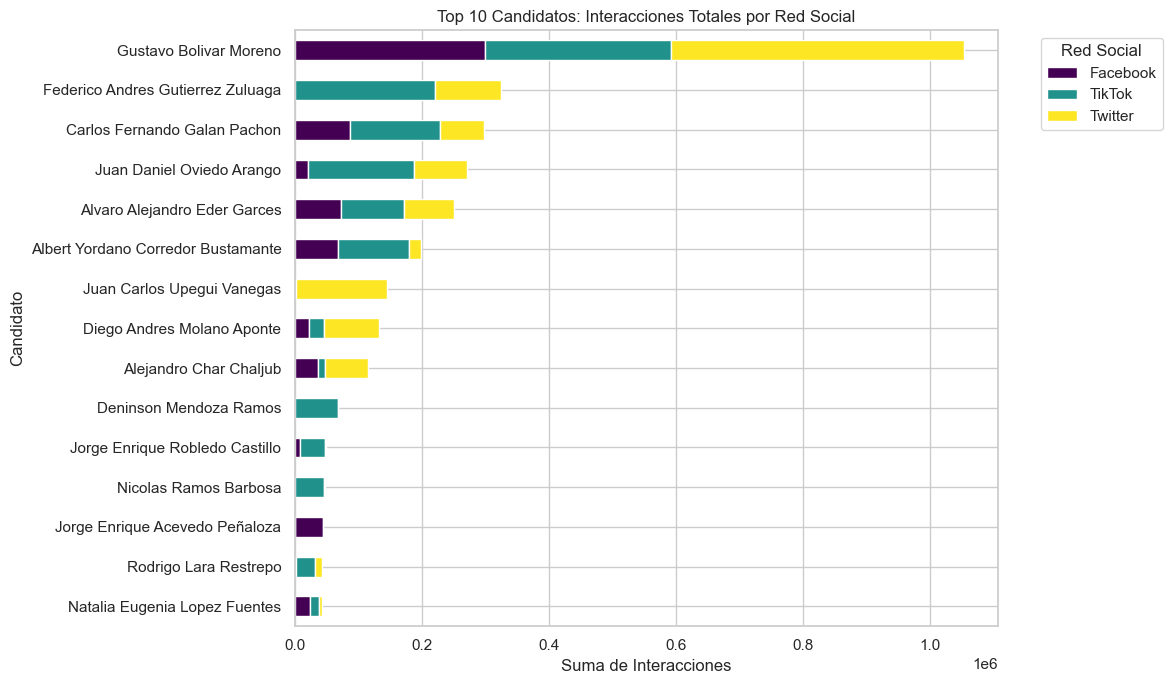

In [42]:
top_nombres = df_completo.groupby('Candidato')['interacciones_totales'].sum().sort_values(ascending=False).head(15).index
df_top = df_completo[df_completo['Candidato'].isin(top_nombres)]
grafico_data = df_top.groupby(['Candidato', 'red_social'])['interacciones_totales'].sum().unstack().fillna(0)
grafico_data = grafico_data.loc[top_nombres]
grafico_data.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Top 10 Candidatos: Interacciones Totales por Red Social')
plt.xlabel('Suma de Interacciones')
plt.ylabel('Candidato')
plt.gca().invert_yaxis()
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Análisis por Red Social
Interacciones promedio por publicación.

In [43]:
promedio_red = df_completo.groupby('red_social')[['likes', 'comentarios', 'compartidos', 'vistas']].mean().round(2)
promedio_red

,likes,comentarios,compartidos,vistas
red_social,,,,
Facebook,392.21,76.11,72.55,9144.64
TikTok,1246.22,59.92,54.68,26154.48
Twitter,338.49,58.02,120.08,16946.03


## 5. Relación entre Interacciones y Éxito Electoral
¿Los ganadores tienen mejores métricas?

In [44]:
# Agrupación por persona
stats_candidato = df_completo.groupby(['id_candidato', 'Candidato', 'Ganador']).agg({
    'interacciones_totales': 'sum',
    'id_candidato': 'count', # num publicaciones
    'Votos': 'first'
}).rename(columns={'id_candidato': 'num_posts'}).reset_index()

stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# Comparativa Ganadores vs No Ganadores
stats_candidato.groupby('Ganador')[['interacciones_totales', 'interacciones_promedio', 'num_posts', 'Votos']].mean().round(2)

,interacciones_totales,interacciones_promedio,num_posts,Votos
Ganador,,,,
No,28011.69,381.09,45.31,44674.43
Sí,44252.86,759.90,52.45,159241.76


In [45]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ganador', y='interacciones_totales', data=stats_candidato)
plt.title('Distribución de Interacciones: Ganadores vs No Ganadores')
plt.yscale('log') # Escala logarítmica para mejor visualización
plt.show()

Estadístico U: 1725.5
P-Valor: 0.0515

 CONCLUSIÓN: La diferencia ES estadísticamente significativa.
Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.

Mediana Ganadores: 12598.0
Mediana No Ganadores: 5662.5


In [46]:
from scipy.stats import mannwhitneyu

# 1. Separar los grupos
ganadores = stats_candidato[stats_candidato['Ganador'] == 'Sí']['interacciones_totales']
no_ganadores = stats_candidato[stats_candidato['Ganador'] == 'No']['interacciones_totales']

# 2. Ejecutar la prueba de Mann-Whitney U
stat, p_value = mannwhitneyu(ganadores, no_ganadores, alternative='two-sided')

# 3. Mostrar resultados
print(f"Estadístico U: {stat}")
print(f"P-Valor: {p_value:.4f}")

# 4. Interpretación científica
alpha = 0.10
if p_value < alpha:
    print("\n CONCLUSIÓN: La diferencia ES estadísticamente significativa.")
    print("Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.")
else:
    print("\n❌ CONCLUSIÓN: La diferencia NO es estadísticamente significativa.")
    print("A pesar de los promedios, no podemos decir que los ganadores tengan consistentemente más interacciones que los perdedores.")

# 5. Ver medianas (son más confiables que los promedios en este caso)
print(f"\nMediana Ganadores: {ganadores.median()}")
print(f"Mediana No Ganadores: {no_ganadores.median()}")


Estadístico U: 1725.5
P-Valor: 0.0515

 CONCLUSIÓN: La diferencia ES estadísticamente significativa.
Hay evidencia suficiente para decir que ganar las elecciones está relacionado con el volumen de interacciones.

Mediana Ganadores: 12598.0
Mediana No Ganadores: 5662.5


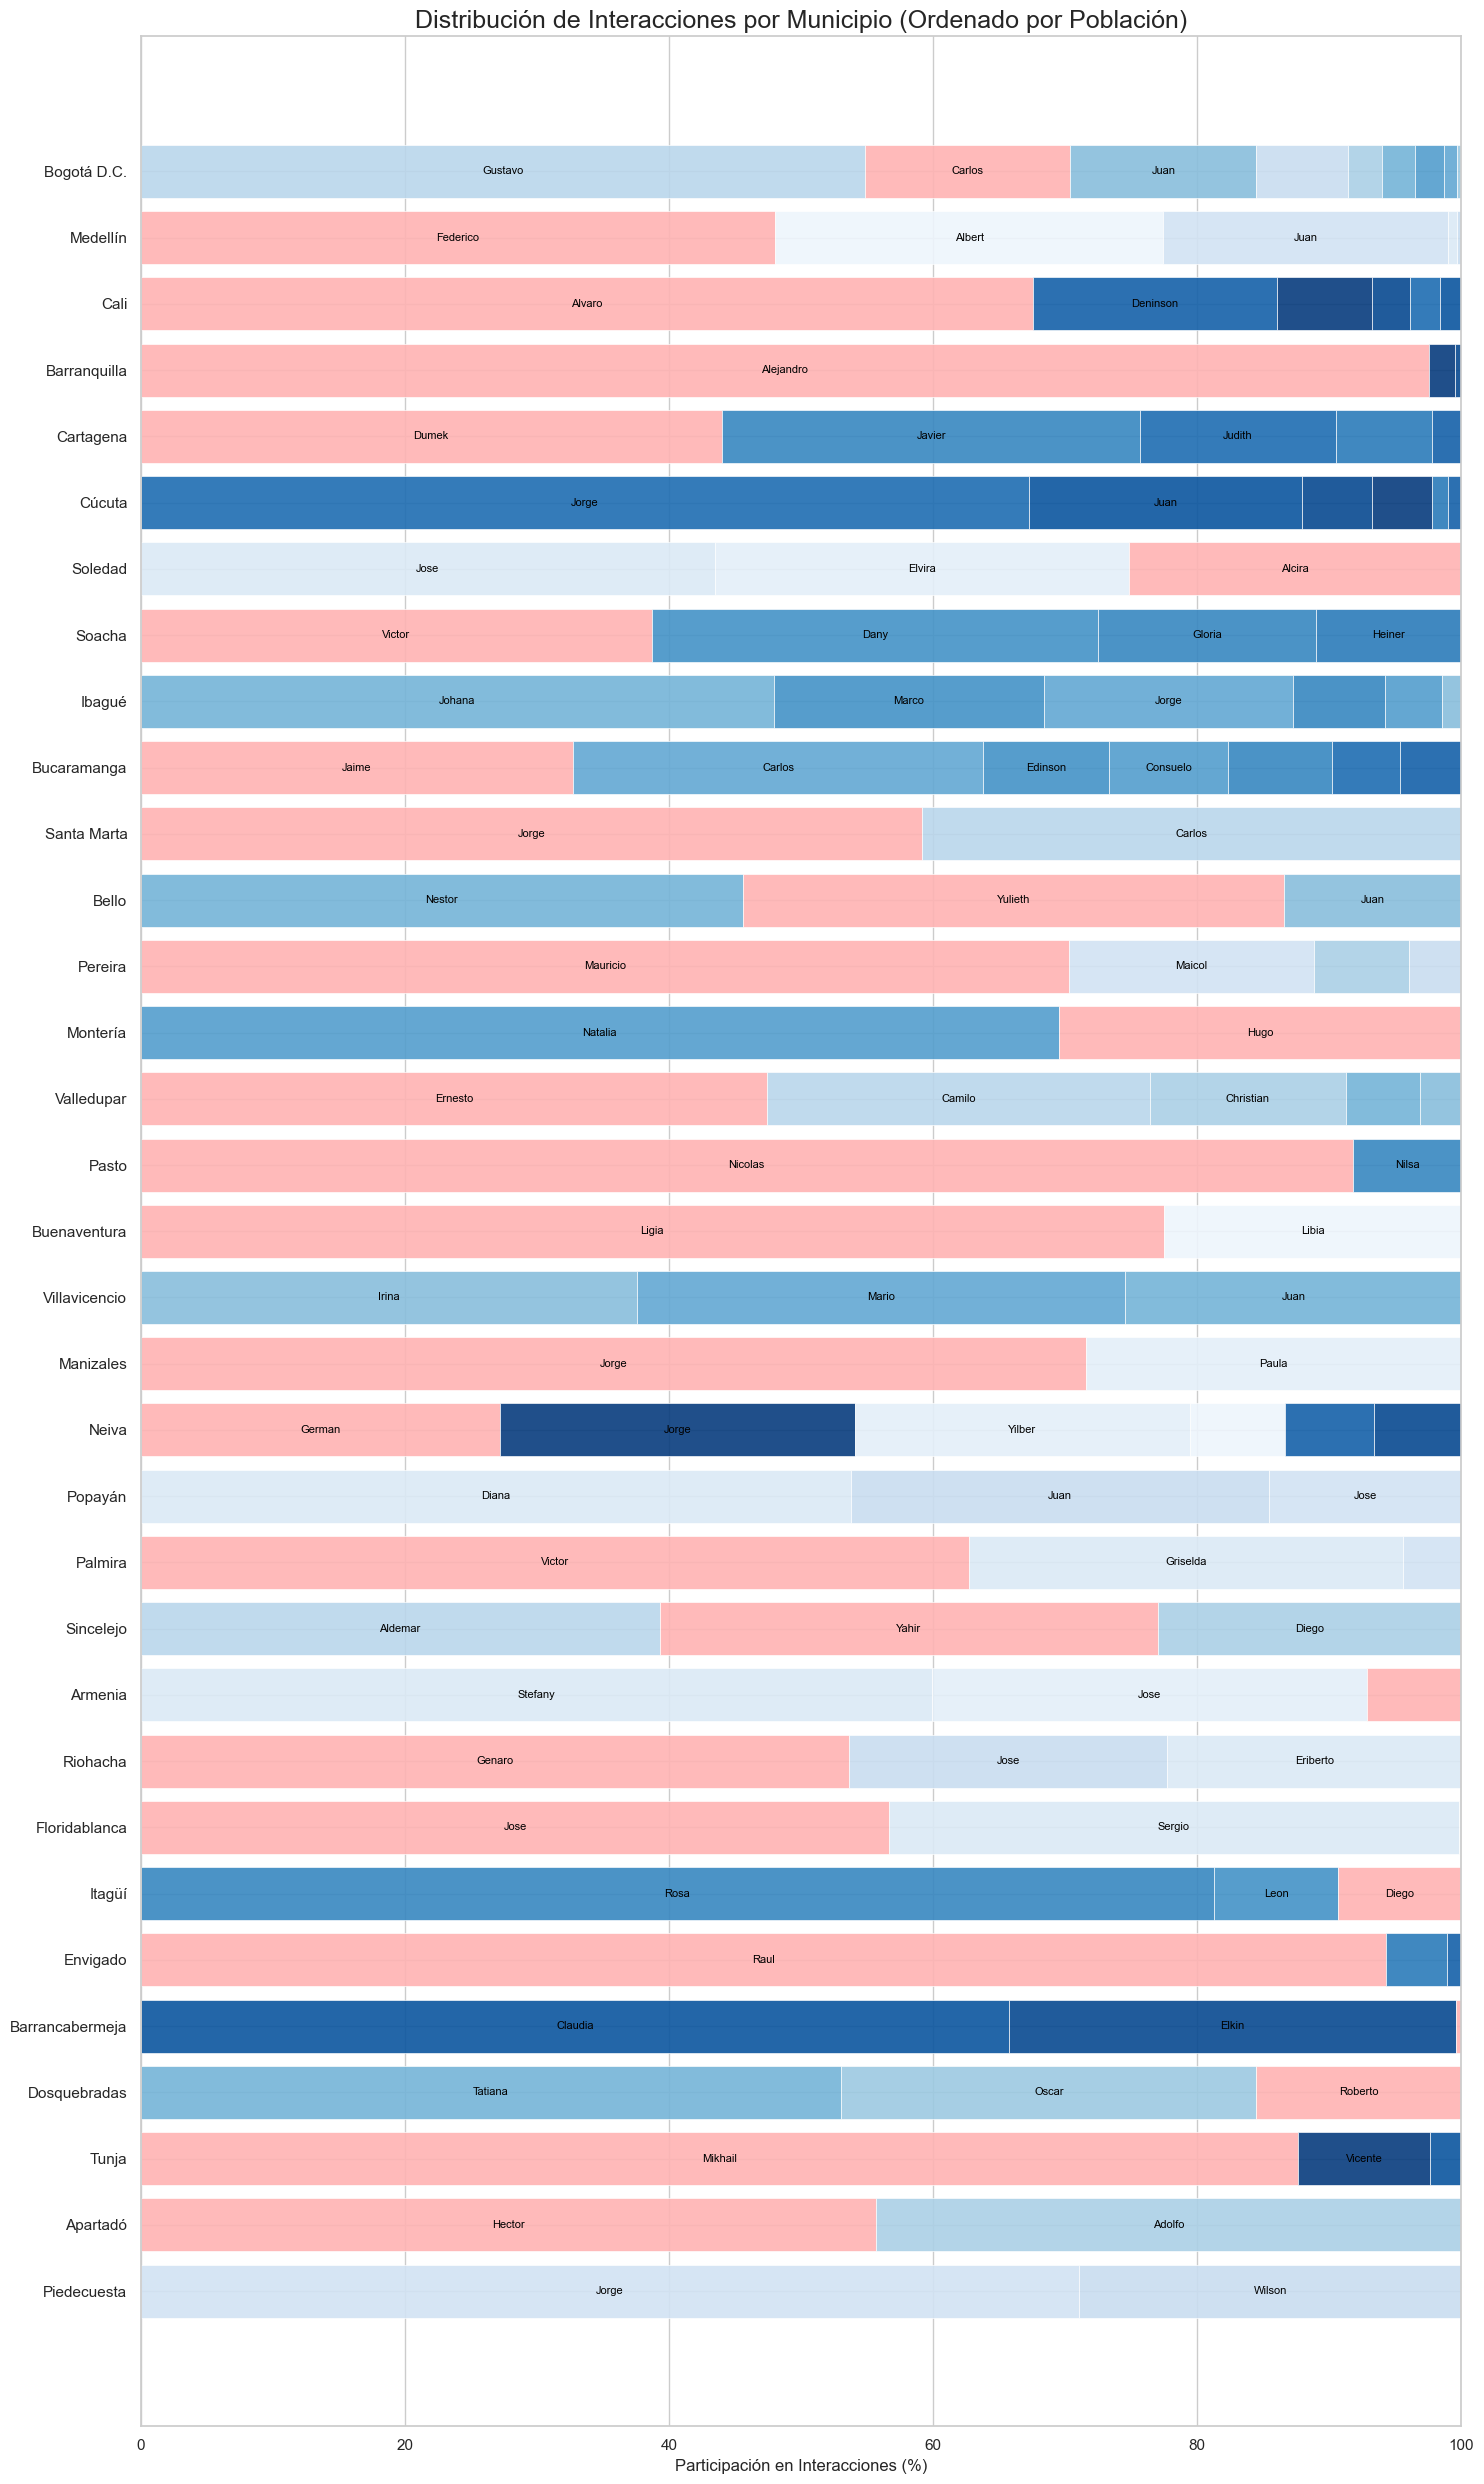

In [72]:
# 1. Cargar y Limpiar Población (Asegurando formato 05001)
df_poblacion = pd.read_excel(excel_path, sheet_name='Población 2023 (DANE)')
df_poblacion['DIVIPOLA'] = pd.to_numeric(df_poblacion['DIVIPOLA'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(5)

# 2. Preparar Candidatos (Extraer DIVIPOLA y calcular interacciones totales)
df_completo['DIVIPOLA'] = df_completo['id_candidato'].astype(str).str.split('-').str[1].str.zfill(5)
# Asegurarnos de que interacciones_totales esté calculada
interact_cols = ['likes', 'comentarios', 'compartidos', 'favoritos']
df_completo['interacciones_totales'] = df_completo[interact_cols].sum(axis=1)

# 3. Agrupar y Calcular Porcentajes
df_muni_stats = df_completo.groupby(['DIVIPOLA', 'Candidato', 'Ganador'])['interacciones_totales'].sum().reset_index()
totales_ciudad = df_muni_stats.groupby('DIVIPOLA')['interacciones_totales'].transform('sum')
df_muni_stats['porcentaje'] = (df_muni_stats['interacciones_totales'] / totales_ciudad) * 100

# 4. Obtener ranking de ciudades por población
ranking_ciudades = df_poblacion.sort_values(by='Población 2023', ascending=False)
ciudades_con_datos = df_muni_stats['DIVIPOLA'].unique()
ranking_filtrado = ranking_ciudades[ranking_ciudades['DIVIPOLA'].isin(ciudades_con_datos)]

# 5. Configuración de la Gráfica Nacional Pastel
fig, ax = plt.subplots(figsize=(15, 25))
competidor_palette = sns.color_palette("Blues", n_colors=20)
rojo_pastel = "#FFB3B3" # Rojo suave

for i, (idx, row_pop) in enumerate(ranking_filtrado.iterrows()):
    divi = row_pop['DIVIPOLA']
    nombre_muni = row_pop['Municipio']
    
    df_m = df_muni_stats[df_muni_stats['DIVIPOLA'] == divi].sort_values(by='porcentaje', ascending=False)
    
    left = 0
    for j, row in df_m.iterrows():
        color = rojo_pastel if row['Ganador'] == 'Sí' else competidor_palette[j % 20]
        
        ax.barh(nombre_muni, row['porcentaje'], left=left, color=color, 
                edgecolor='white', linewidth=0.5, alpha=0.9)
        
        # Etiqueta de nombre solo si el segmento es representativo (>8%)
        if row['porcentaje'] > 8:
            ax.text(left + row['porcentaje']/2, i, row['Candidato'].split()[0], 
                    va='center', ha='center', color='black', fontsize=8)
        left += row['porcentaje']

ax.set_title('Distribución de Interacciones por Municipio (Ordenado por Población)', fontsize=18)
ax.set_xlabel('Participación en Interacciones (%)')
ax.set_xlim(0, 100)
ax.invert_yaxis() 

plt.tight_layout()
plt.show()


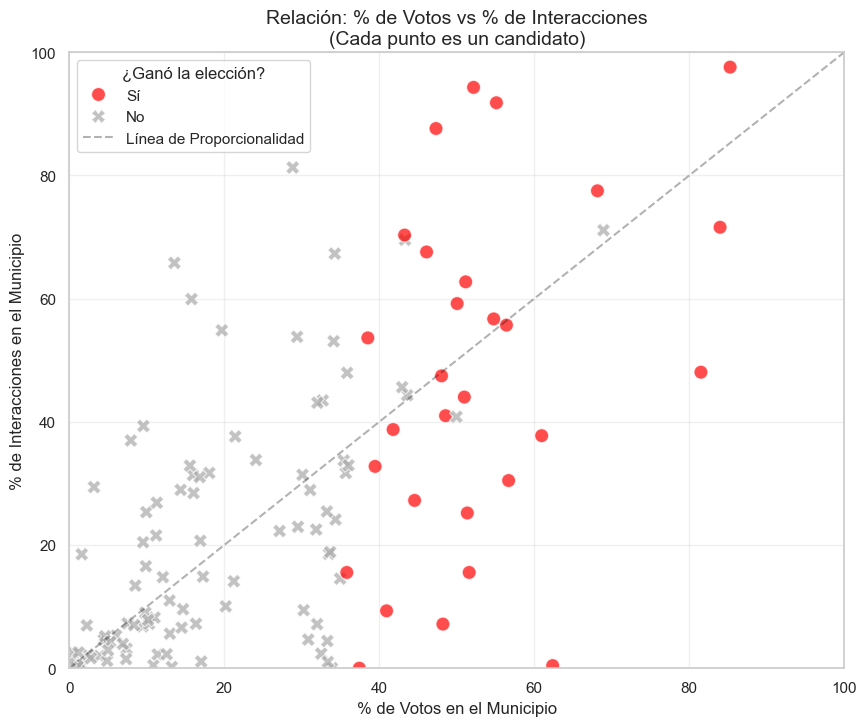

In [74]:
# 1. Preparar los datos agrupados por candidato y municipio
# Aseguramos que tenemos DIVIPOLA y votos en stats_candidato
stats_candidato['DIVIPOLA'] = stats_candidato['id_candidato'].str.split('-').str[1].str.zfill(5)

# 2. Calcular totales por municipio para sacar porcentajes
totales_muni = stats_candidato.groupby('DIVIPOLA').agg({
    'interacciones_totales': 'sum',
    'Votos': 'sum'
}).rename(columns={'interacciones_totales': 'total_interact_muni', 'Votos': 'total_votos_muni'})

# 3. Unir totales al dataframe de estadísticas
df_scatter = pd.merge(stats_candidato, totales_muni, on='DIVIPOLA', how='left')

# 4. Calcular los dos porcentajes (Ejes X e Y)
df_scatter['pct_votos'] = (df_scatter['Votos'] / df_scatter['total_votos_muni']) * 100
df_scatter['pct_interact'] = (df_scatter['interacciones_totales'] / df_scatter['total_interact_muni']) * 100

# 5. Graficar
plt.figure(figsize=(10, 8))

# Usamos scatterplot de seaborn para manejar el color por 'Ganador'
sns.scatterplot(
    data=df_scatter,
    x='pct_votos',
    y='pct_interact',
    hue='Ganador',
    palette={'Sí': '#FF0000', 'No': '#A9A9A9'}, # Rojo para ganador, Gris para el resto
    style='Ganador',
    s=100,
    alpha=0.7
)

# Añadir una línea de 45 grados para ver la "proporcionalidad"
plt.plot([0, 100], [0, 100], color='black', linestyle='--', alpha=0.3, label='Línea de Proporcionalidad')

plt.title('Relación: % de Votos vs % de Interacciones\n(Cada punto es un candidato)', fontsize=14)
plt.xlabel('% de Votos en el Municipio')
plt.ylabel('% de Interacciones en el Municipio')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(title='¿Ganó la elección?')
plt.grid(True, alpha=0.3)

plt.show()


In [ ]:
# 1. Identificar al candidato con más interacciones por cada municipio
idx_max_interact = df_scatter.groupby('DIVIPOLA')['pct_interact'].idxmax()
lideres_redes = df_scatter.loc[idx_max_interact]

# 2. Contar en cuántos de esos casos el líder de redes es también el ganador
aciertos = lideres_redes[lideres_redes['Ganador'] == 'Sí']
total_municipios = len(lideres_redes)
num_aciertos = len(aciertos)

# 3. Calcular el porcentaje final
tasa_acierto = (num_aciertos / total_municipios) * 100

print(f"--- Análisis de Predicción (Redes vs Urnas) ---")
print(f"Total de municipios analizados: {total_municipios}")
print(f"Casos donde el líder de redes GANÓ: {num_aciertos}")
print(f"Tasa de Acierto: {tasa_acierto:.2f}%")


--- Análisis de Predicción (Redes vs Urnas) ---
Total de municipios analizados: 33
Casos donde el líder de redes GANÓ: 19
Tasa de Acierto: 57.58%

✅ En el 57.58% de los casos, dominar las redes sociales fue un indicador directo de victoria.


## **2. Análisis por interacciones promedio por post**

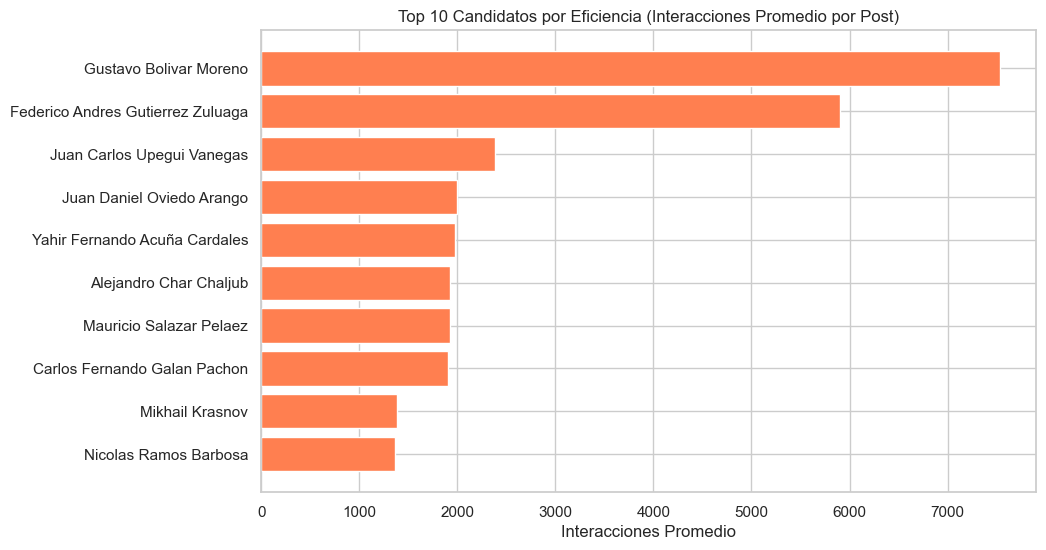

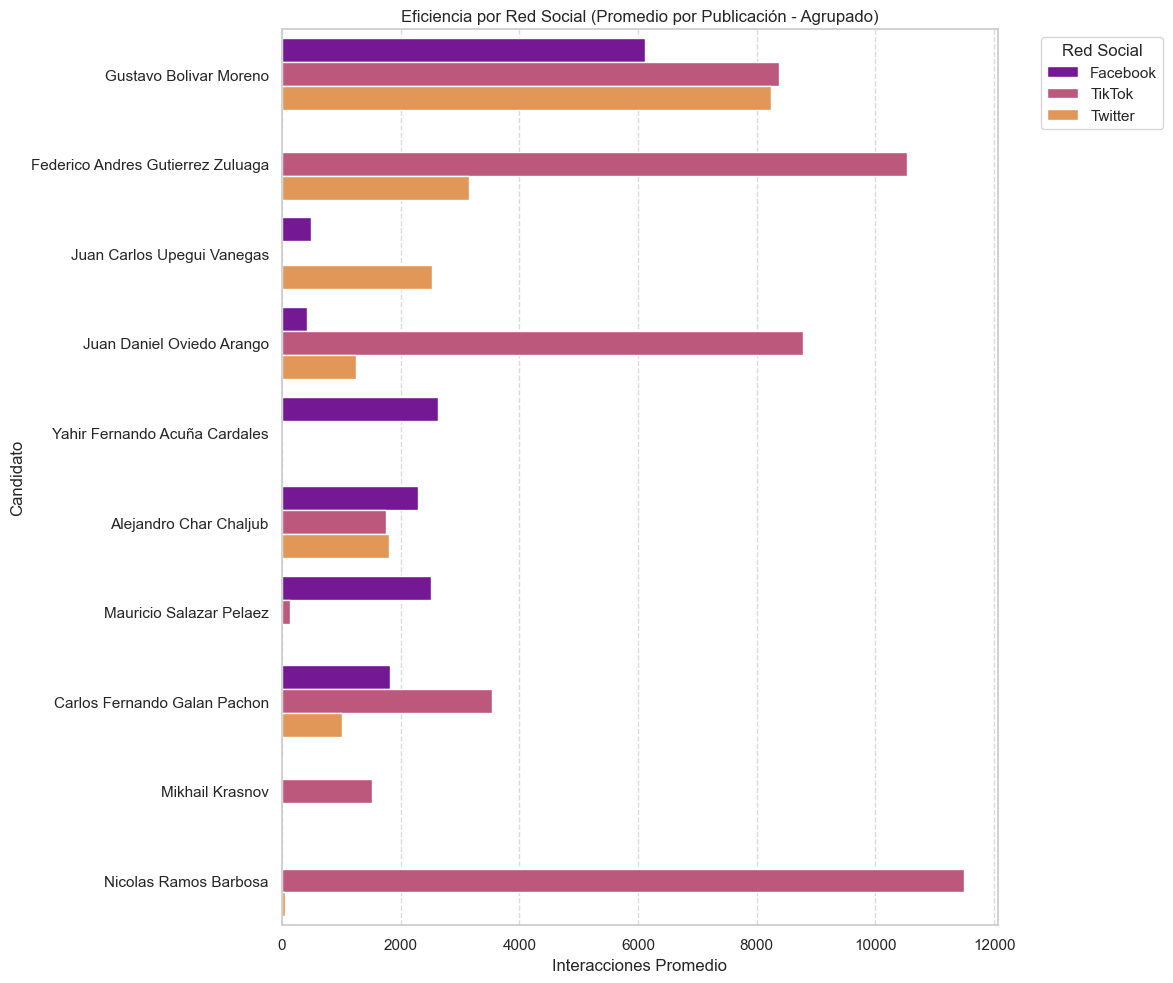

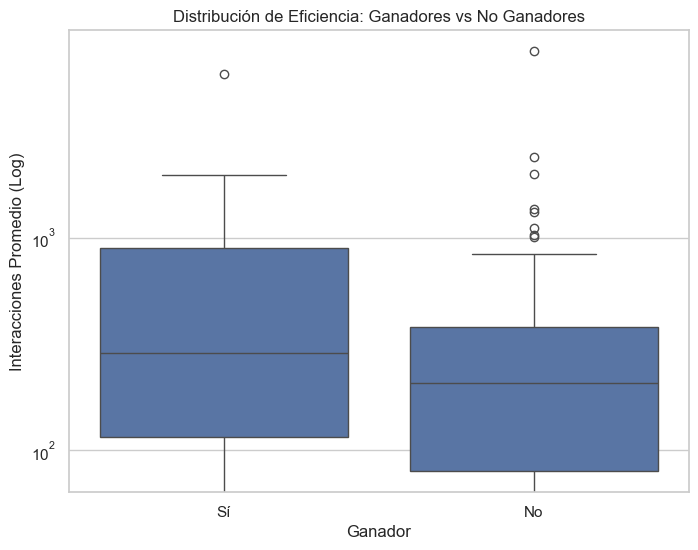


--- Prueba Mann-Whitney U para Interacciones Promedio ---
P-Valor: 0.0481
SIGNIFICATIVO AL 95%: La eficiencia de publicación sí distingue a los ganadores.


In [48]:
# 1. Asegurarnos de que tenemos la métrica de promedio por post en stats_candidato
stats_candidato['interacciones_promedio'] = (stats_candidato['interacciones_totales'] / stats_candidato['num_posts']).round(2)

# --- GRÁFICA 1: TOP 10 POR PROMEDIO ---
top_10_prom = stats_candidato.sort_values(by='interacciones_promedio', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_prom['Candidato'], top_10_prom['interacciones_promedio'], color='coral')
plt.title('Top 10 Candidatos por Eficiencia (Interacciones Promedio por Post)')
plt.xlabel('Interacciones Promedio')
plt.gca().invert_yaxis()
plt.show()

# --- GRÁFICA 2: TOP 10 POR RED SOCIAL (PROMEDIO) ---
# Usamos el mismo top 10 de nombres para filtrar
plt.figure(figsize=(12, 10))

# Usamos barplot de Seaborn que maneja las agrupaciones (hue) de forma nativa
sns.barplot(
    data=df_top_10_prom,
    y='Candidato',
    x='interacciones_totales',
    hue='red_social',
    estimator='mean',      # Importante: aquí le pedimos que calcule el promedio
    errorbar=None,         # Quitamos las líneas de error para que se vea más limpio
    order=top_10_nombres_prom, # Mantenemos el orden del Top 10
    palette='plasma'
)

plt.title('Eficiencia por Red Social (Promedio por Publicación - Agrupado)')
plt.xlabel('Interacciones Promedio')
plt.ylabel('Candidato')
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- GRÁFICA 3: BOXPLOT DE DISTRIBUCIÓN DE PROMEDIOS ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ganador', y='interacciones_promedio', data=stats_candidato)
plt.title('Distribución de Eficiencia: Ganadores vs No Ganadores')
plt.yscale('log')
plt.ylabel('Interacciones Promedio (Log)')
plt.show()

# --- PRUEBA DE HIPÓTESIS (90% CONFIANZA) ---
from scipy.stats import mannwhitneyu

ganadores_prom = stats_candidato[stats_candidato['Ganador'] == 'Sí']['interacciones_promedio']
no_ganadores_prom = stats_candidato[stats_candidato['Ganador'] == 'No']['interacciones_promedio']

stat_p, p_value_p = mannwhitneyu(ganadores_prom, no_ganadores_prom, alternative='two-sided')

print(f"\n--- Prueba Mann-Whitney U para Interacciones Promedio ---")
print(f"P-Valor: {p_value_p:.4f}")

if p_value_p < 0.05:
    print("SIGNIFICATIVO AL 95%: La eficiencia de publicación sí distingue a los ganadores.")
else:
    print("NO SIGNIFICATIVO: Ni siquiera la eficiencia por post garantiza la victoria.")
